# Klasifikasi Spasial Lahan Sawah dan Non-Sawah Menggunakan Citra Sentinel-2A di Kecamatan Labang
tahapan akuisisi citra satelit optik **Sentinel-2A (Level-2A)** dalam format GeoTIFF (`.tif`), ekstraksi nilai spektral dan fitur spasial pada titik sampel (berdasarkan data QGIS wilayah Kecamatan Labang: `Qgis_sawah.qgs` dan `Qgis_nonsawah.qgs`), hingga pemodelan klasifikasi biner (2 kelas: Sawah dan Non-Sawah).

## Instalasi Library Yang Digunakan

In [1]:
!pip install geopandas openeo scikit-learn matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
pip install openeo

### 1. Desain Pengambilan Sampel (Ground Truth)

Proses pengambilan sampel ground truth dilakukan berdasarkan lokasi atau posisi objek di wilayah penelitian. Sampel dibagi menjadi dua kelas, yaitu sawah dan non-sawah, dengan jumlah yang sama pada masing-masing kelas agar data yang digunakan bersifat seimbang (balanced dataset). Data sampel dibuat dalam bentuk data vektor seperti Shapefile atau GeoJSON.

| Kelas Target  | Label |  Jumlah Sampel | Keterangan Objek                                                                                                                                                  |
| ------------- | :---: | :------------: | ----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Sawah**     |  `1`  |    50 sampel   | Area yang digunakan sebagai lahan pertanian padi, baik pada kondisi vegetasi awal, lahan yang masih tergenang atau baru ditanami, maupun pada tahap menuju panen. |
| **Non-Sawah** |  `0`  |    50 sampel   | Area yang bukan merupakan lahan sawah, seperti permukiman, bangunan, jalan, perairan permanen, serta vegetasi yang tidak digunakan untuk pertanian.               |
| **Total**     |   —   | **100 sampel** | Seluruh sampel dari kedua kelas digabungkan menjadi satu *GeoDataFrame* dengan sistem koordinat **EPSG:4326**.                                                    |


In [5]:
import geopandas as gpd
import openeo
import pandas as pd
from google.colab import files

# 1. PILIH FILE ZIP SAWAH DAN NON-SAWAH

print("Pilih file ZIP SAWAH...")
upload_sawah = files.upload()

print("Pilih file ZIP NON-SAWAH...")
upload_nonsawah = files.upload()

nama_file_sawah = list(upload_sawah.keys())[0]
nama_file_nonsawah = list(upload_nonsawah.keys())[0]

print("File Sawah     :", nama_file_sawah)
print("File Non-Sawah :", nama_file_nonsawah)

# 2. BACA FILE ZIP

gdf_sawah = gpd.read_file(nama_file_sawah).to_crs("EPSG:4326")
gdf_nonsawah = gpd.read_file(nama_file_nonsawah).to_crs("EPSG:4326")

# Label sawah
gdf_sawah["label_teks"] = "Sawah"
gdf_sawah["label"] = 1

# Label non-sawah
gdf_nonsawah["label_teks"] = "Non-Sawah"
gdf_nonsawah["label"] = 0


# 3. GABUNGKAN DATA

gdf_gabungan = gpd.GeoDataFrame(
    pd.concat(
        [gdf_sawah, gdf_nonsawah],
        ignore_index=True
    ),
    crs="EPSG:4326"
)

print()
print("Jumlah sampel Sawah     :", len(gdf_sawah))
print("Jumlah sampel Non-Sawah :", len(gdf_nonsawah))
print("Total sampel gabungan   :", len(gdf_gabungan))


# 4. MEMBUAT BOUNDING BOX

minx, miny, maxx, maxy = gdf_gabungan.total_bounds

buffer_deg = 0.005

bbox = {
    "west": float(minx - buffer_deg),
    "south": float(miny - buffer_deg),
    "east": float(maxx + buffer_deg),
    "north": float(maxy + buffer_deg),
}

print()
print("Bounding Box Gabungan:")
print(bbox)

# 5. KONEKSI KE OPENEO

print()
print("Menghubungkan ke openEO...")

conn = openeo.connect(
    "openeo.dataspace.copernicus.eu"
)

conn.authenticate_oidc()

# 6. AMBIL DATA SENTINEL-2

datacube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=[
        "2026-05-01",
        "2026-09-30"
    ],
    bands=[
        "B02",  # Blue
        "B03",  # Green
        "B04",  # Red
        "B08",  # NIR
        "B11",  # SWIR
    ],
    max_cloud_cover=10,
)

# 7. MEDIAN COMPOSITE

print()
print("Membuat median composite...")

composite_s2 = datacube.median_time()


# 8. DOWNLOAD CITRA SENTINEL-2

nama_tif = "sentinel2_sawah_nonsawah.tif"

print()
print("Mengunduh citra Sentinel-2...")
print("Mohon tunggu sampai proses selesai...")

composite_s2.download(
    nama_tif,
    format="GTiff"
)

print()
print("==============================================")
print("CITRA SENTINEL-2 BERHASIL DIUNDUH DI COLAB")
print("Nama file:", nama_tif)
print("==============================================")


# 9. OTOMATIS DOWNLOAD KE KOMPUTER

print()
print("Mengirim file ke komputer...")

files.download(nama_tif)

print("Download otomatis dimulai.")

Pilih file ZIP SAWAH...


Saving sawah.zip to sawah (1).zip
Pilih file ZIP NON-SAWAH...


Saving non-sawah.zip to non-sawah (1).zip
File Sawah     : sawah (1).zip
File Non-Sawah : non-sawah (1).zip

Jumlah sampel Sawah     : 50
Jumlah sampel Non-Sawah : 50
Total sampel gabungan   : 100

Bounding Box Gabungan:
{'west': 112.7744819, 'south': -7.1646237, 'east': 112.8107545, 'north': -7.1160198}

Menghubungkan ke openEO...
Authenticated using refresh token.

Membuat median composite...

Mengunduh citra Sentinel-2...
Mohon tunggu sampai proses selesai...

CITRA SENTINEL-2 BERHASIL DIUNDUH DI COLAB
Nama file: sentinel2_sawah_nonsawah.tif

Mengirim file ke komputer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download otomatis dimulai.


### 2. Pengunduhan Citra Sentinel-2A Berformat `.tif` via openEO Beserta Ekstraksi Fitur Spasial

Tahap perolehan citra satelit dilakukan dengan memanfaatkan batasan wilayah (*bounding box*) yang mencakup titik-titik sampel pengamatan di **Kecamatan Labang**. Sumber data menggunakan koleksi `SENTINEL2_L2A` (*Bottom-of-Atmosphere Reflectance*) dengan ketentuan persentase tutupan awan maksimum di bawah 10%. Selain itu, diterapkan fungsi agregasi waktu `median_time()` guna menyusun komposit citra yang bersih dari awan dan berformat akhir GeoTIFF (`.tif`).

### **Variabel Spektral dan Parameter Turunan yang Diekstrak:**

1. **Band Spektral Inti:**
   * **B02** (Spektrum Biru / *Blue* - 490 nm), **B03** (Spektrum Hijau / *Green* - 560 nm), dan **B04** (Spektrum Merah / *Red* - 665 nm) yang memiliki tingkat resolusi spasial 10 meter.
   * **B08** (*Near Infrared* / NIR - 842 nm) yang diandalkan untuk membaca intensitas pantulan klorofil dari tanaman padi di lahan sawah.
   * **B11** (*Short-Wave Infrared* / SWIR - 1610 nm) yang berguna dalam memetakan tingkat kelembapan tanah serta sebaran genangan air.

2. **Indeks Perbedaan Vegetasi Terstandardisasi (NDVI):**
   $$\text{NDVI} = \frac{B08 - B04}{B08 + B04}$$

3. **Indeks Perbedaan Air Terstandardisasi (NDWI):**
   $$\text{NDWI} = \frac{B03 - B08}{B03 + B08}$$

In [6]:
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Buka file .tif Sentinel-2A dan samakan proyeksi koordinat (CRS)
with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  gdf_projected = gdf_gabungan.to_crs(src.crs)

  # Ambil titik tengah (centroid) dari tiap sampel (mendukung Point maupun Polygon)
  koordinat_sampel = [
      (geom.centroid.x, geom.centroid.y) for geom in gdf_projected.geometry
  ]

  # Ekstrak nilai piksel dari kelima band Sentinel-2A
  nilai_band = list(src.sample(koordinat_sampel))

# 2. Buat tabel DataFrame Fitur
df_dataset = pd.DataFrame(nilai_band, columns=["B02", "B03", "B04", "B08", "B11"])

# 3. Tambahkan fitur indeks vegetasi (NDVI) & indeks air (NDWI)
df_dataset["NDVI"] = (df_dataset["B08"] - df_dataset["B04"]) / (
    df_dataset["B08"] + df_dataset["B04"] + 1e-6
)
df_dataset["NDWI"] = (df_dataset["B03"] - df_dataset["B08"]) / (
    df_dataset["B03"] + df_dataset["B08"] + 1e-6
)

# 4. Masukkan Koordinat & Label Kelas (Sawah = 1, Non-Sawah = 0)
df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y
df_dataset["Kelas"] = gdf_gabungan["label_teks"]
df_dataset["Target"] = gdf_gabungan["label"]

# Simpan ke CSV (bisa dipakai juga kalau mau diolah di KNIME)
df_dataset.to_csv("dataset_100sampel_sawah_nonsawah.csv", index=False)
print("Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'")
display(df_dataset.head())

# 5. PROSES KLASIFIKASI 2 KELAS (SAWAH VS NON-SAWAH)
fitur_kolom = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"]
X = df_dataset[fitur_kolom]
y = df_dataset["Kelas"]

# Split 80% Training (40 Sawah + 40 Non-Sawah) & 20% Testing (10 Sawah + 10 Non-Sawah)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Latih model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Evaluasi pada data uji
y_pred = model_rf.predict(X_test)
print(
    "\n=== HASIL EVALUASI KLASIFIKASI 2 KELAS ==="
)
print(f"Akurasi Testing : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'


/tmp/ipykernel_545/1318281886.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
/tmp/ipykernel_545/1318281886.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y


,B02,B03,B04,B08,B11,NDVI,NDWI,Longitude,Latitude,Kelas,Target
0,428,739,575,2868,2673,0.665989,-0.590241,112.800248,-7.125815,Sawah,1
1,478,796,814,2498,2646,0.508454,-0.516697,112.799436,-7.126719,Sawah,1
2,820,1101,1532,2652,3209,0.267686,-0.413269,112.802724,-7.126770,Sawah,1
3,895,1199,1558,2877,3561,0.297407,-0.411678,112.798765,-7.123868,Sawah,1
4,501,820,944,2235,2621,0.406103,-0.463175,112.797995,-7.127865,Sawah,1



=== HASIL EVALUASI KLASIFIKASI 2 KELAS ===
Akurasi Testing : 100.00%

Confusion Matrix:
 [[10  0]
 [ 0 10]]

Classification Report:
               precision    recall  f1-score   support

   Non-Sawah       1.00      1.00      1.00        10
       Sawah       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [7]:
pip install seaborn

### 3. Analisis Kinerja Klasifikasi Biner (*Random Forest*)

Penerapan pemodelan biner ini menggunakan total 100 titik sampel yang dibagi secara proporsional melalui teknik *Stratified Train-Test Split*. Dari keseluruhan data tersebut, sebanyak 80% dialokasikan sebagai data pelatihan (berisi 80 sampel yang terbagi rata masing-masing 40 untuk kelas Sawah dan Non-Sawah), sementara 20% sisanya difungsikan sebagai data pengujian atau evaluasi (terdiri dari 20 sampel dengan rincian 10 sampel Sawah dan 10 sampel Non-Sawah).

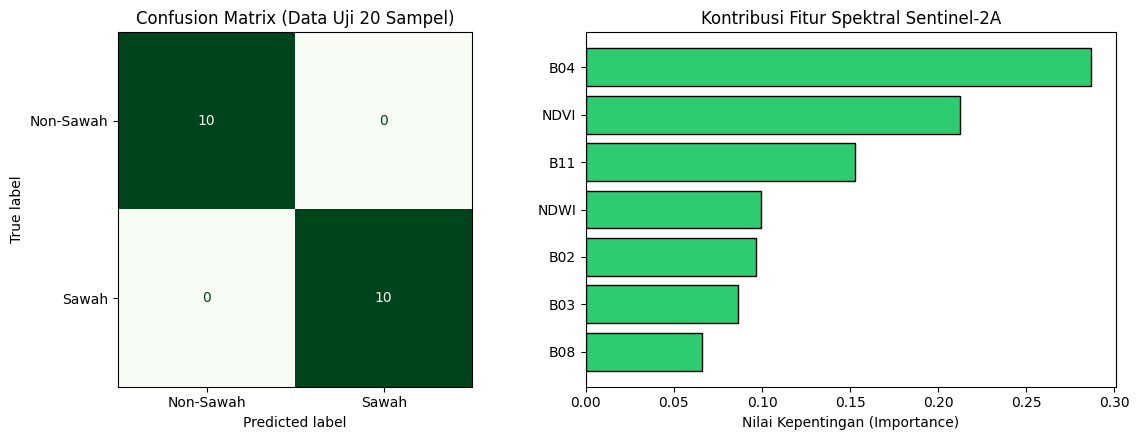

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


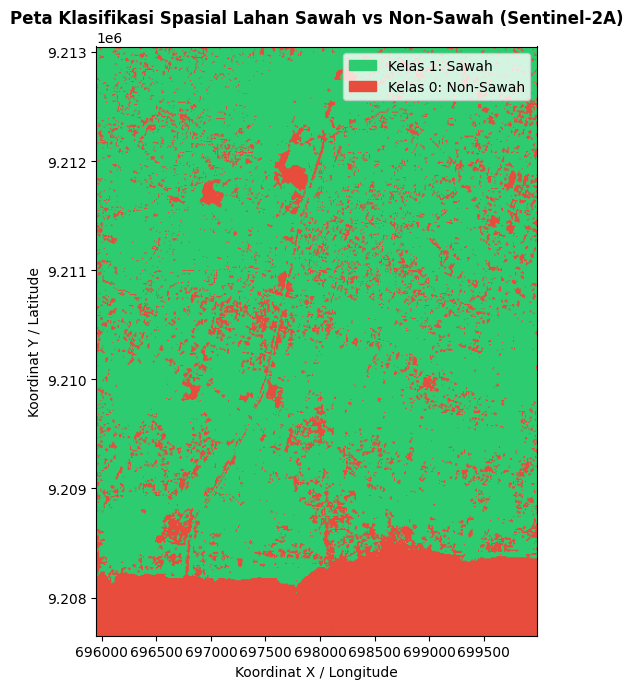

In [8]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# ==============================================================================
# A. VISUALISASI CONFUSION MATRIX & FEATURE IMPORTANCE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Greens", ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix (Data Uji 20 Sampel)")

# 2. Plot Tingkat Kepentingan Fitur (Band & Indeks Spektral)
importances = model_rf.feature_importances_
indices = np.argsort(importances)
axes[1].barh(
    range(len(indices)),
    importances[indices],
    color="#2ecc71",
    edgecolor="black",
)
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([fitur_kolom[i] for i in indices])
axes[1].set_xlabel("Nilai Kepentingan (Importance)")
axes[1].set_title("Kontribusi Fitur Spektral Sentinel-2A")

plt.tight_layout()
plt.savefig("evaluasi_klasifikasi_sawah.png", dpi=300)
plt.show()

# B. KLASIFIKASI SELURUH PIKSEL CITRA (.TIF) MENJADI PETA SAWAH VS NON-SAWAH
with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  img = src.read()  # Shape: (5 bands, height, width)
  profil_raster = src.profile
  bounds = src.bounds

# Ambil masing-masing band (B02, B03, B04, B08, B11)
b02, b03, b04, b08, b11 = (
    img[0].astype(float),
    img[1].astype(float),
    img[2].astype(float),
    img[3].astype(float),
    img[4].astype(float),
)

# Hitung NDVI dan NDWI untuk seluruh piksel di citra .tif
ndvi_map = (b08 - b04) / (b08 + b04 + 1e-6)
ndwi_map = (b03 - b08) / (b03 + b08 + 1e-6)

# Susun seluruh piksel menjadi matriks 2D (baris = piksel, kolom = 7 fitur)
stack_fitur = np.stack([b02, b03, b04, b08, b11, ndvi_map, ndwi_map], axis=-1)
h, w, c = stack_fitur.shape
piksel_2d = np.nan_to_num(stack_fitur.reshape(-1, c), nan=0.0)

# Prediksi seluruh piksel menggunakan model Random Forest yang sudah dilatih
prediksi_label = model_rf.predict(piksel_2d)

# Ubah hasil prediksi ('Sawah' -> 1, 'Non-Sawah' -> 0) kembali ke ukuran gambar 2D (h, w)
peta_biner = np.where(prediksi_label == "Sawah", 1, 0).reshape(h, w)

# Tampilkan Peta Hasil Klasifikasi Spasial
plt.figure(figsize=(9, 7))
cmap_sawah = mcolors.ListedColormap(["#e74c3c", "#2ecc71"])  # Merah & Hijau
plt.imshow(
    peta_biner,
    cmap=cmap_sawah,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
)

# Legenda Peta
patch_sawah = mpatches.Patch(color="#2ecc71", label="Kelas 1: Sawah")
patch_nonsawah = mpatches.Patch(color="#e74c3c", label="Kelas 0: Non-Sawah")
plt.legend(handles=[patch_sawah, patch_nonsawah], loc="upper right")
plt.title(
    "Peta Klasifikasi Spasial Lahan Sawah vs Non-Sawah (Sentinel-2A)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Koordinat X / Longitude")
plt.ylabel("Koordinat Y / Latitude")
plt.tight_layout()
plt.savefig("peta_klasifikasi_raster_sawah.png", dpi=300)
plt.show()